In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
BAKERY = 'Проспект Победы 147 Казань'
SKU_1 = 'Треугольник курица безд'
SKU_2 = 'Вак-бэлиш'
SKU_3 = 'Треугольник говядина безд'
SKU_4 = 'Кыстыбый П'

In [ ]:
df = pd.read_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/raw/sales_hrs_all.csv')

In [3]:
df['Дата продажи'] = pd.to_datetime(df['Дата продажи'], errors="coerce", dayfirst=True)
df['Дата время чека'] = pd.to_datetime(df['Дата время чека'], errors="coerce", dayfirst=True)

df["date"] = df['Дата продажи'].dt.normalize()
df["hour"] = df['Дата время чека'].dt.hour

In [12]:
df.columns

Index(['Дата продажи', 'Дата время чека', 'Вид события по кассе',
       'Касса.Торговая точка', 'Категория', 'Номенклатура', 'Свежесть', 'Цена',
       'Кол-во'],
      dtype='object')

In [9]:
np.sort(df['Касса.Торговая точка'].unique().tolist())

array(['19 квартал 8/1 Казань Куюки', '2-я юго-западная 30 Казань',
       'Аббасова 4 Казань', 'Автозаводский Проспект 28/14 Наб Челны',
       'Адоратского 31Б Казань', 'Адоратского 38Д Казань',
       'Азата Аббасова 10 Казань', 'Айдарова 8А корп 1 Казань',
       'Альфии Авзаловой 5 Казань', 'Амирхана 17 Казань',
       'Арсланова 13 Казань', 'Б. Хмельницкого 109/3 Чебоксары',
       'Баки Урманче 6 Казань', 'Баки Урманче 9 Казань',
       'Баумана 29/11 Казань', 'Белинского 1/3 Казань',
       'Белинского 1/5 Казань', 'Белинского 9/6 Казань',
       'Беломорская 238 Казань', 'Беломорская 6 Казань',
       'Бигичева 16А Казань', 'Братьев Батталовых 27 Казань',
       'Булатова 1А Казань', 'Бызова 8 Нижнекамск', 'Вагапова 3 Казань',
       'Вахитова 20 Наб Челны', 'Винокурова 28 Новочебоксарск',
       'Вишневского 8/35 Казань', 'Восстания 117 Казань',
       'Габдуллы Тукая 62А Казань', 'Гаврилова 40 Казань',
       'Гагарина 17 Зеленодольск', 'Гагарина 17Б Чебоксары',
       'Гидр

In [11]:
len(np.sort(df[df['Касса.Торговая точка'] == 'Ямашева 19А Казань']['Номенклатура'].unique().tolist()))

260

In [40]:
df1 = df[(df['Касса.Торговая точка'] == BAKERY) & (df['Номенклатура'] == SKU_1)]
df2 = df[(df['Касса.Торговая точка'] == BAKERY) & (df['Номенклатура'] == SKU_2)]
df3 = df[(df['Касса.Торговая точка'] == BAKERY) & (df['Номенклатура'] == SKU_3)]
df4 = df[(df['Касса.Торговая точка'] == BAKERY) & (df['Номенклатура'] == SKU_4)]

In [43]:
df1.groupby(['date', 'hour'],as_index=False)['Кол-во'].sum().rename(columns={'Кол-во': "bakery_hour_qty"})

,date,hour,bakery_hour_qty
0,2025-08-01,7,6.0
1,2025-08-01,8,6.0
2,2025-08-01,9,4.0
3,2025-08-01,12,2.0
4,2025-08-01,13,3.0
...,...,...,...
2552,2026-04-02,16,4.0
2553,2026-04-02,17,7.0
2554,2026-04-02,18,4.0
2555,2026-04-02,19,2.0


In [ ]:
def df_proccessing(df):
    # 1. Базовая фильтрация
    df_bakery = df[df['Касса.Торговая точка'] == BAKERY]
    
    # 2. Общие продажи пекарни (оставляем в индексе для деления)
    bakery_hour = df_bakery.groupby(['date', 'hour'])['Кол-во'].sum().rename('bakery_total')
    
    # Создаем базу для будущей таблицы (с колонками date, hour, week)
    hourly_base = bakery_hour.reset_index()
    hourly_base['week'] = hourly_base['date'].dt.day_of_week

    w_h_profiles = []
    shares_list = [] # Список для сбора колонок share
    skus_sales = []
    
    skus = [SKU_1, SKU_2, SKU_3, SKU_4]

    for i, sku_name in enumerate(skus, start=1):
        col_name = f"SKU_{i}_share"
        
        # Считаем продажи SKU
        sku_sales = df_bakery[df_bakery['Номенклатура'] == sku_name].groupby(['date', 'hour'])['Кол-во'].sum()
        skus_sales.append(sku_sales)
        # Считаем долю (Pandas сопоставит индексы date/hour сам)
        share_series = (sku_sales / bakery_hour).rename(col_name).fillna(0)
        print(len(share_series))
        shares_list.append(share_series)

        # Подготовка данных для профиля
        share_df = share_series.reset_index()
        share_df['week'] = share_df['date'].dt.day_of_week

        # Считаем профиль (средняя доля по дню недели и часу)
        # 1. Считаем базовый профиль (средняя доля по дню недели и часу)
        profile_raw = share_df.groupby(['week', 'hour'], as_index=False)[col_name].mean()

        # 2. Считаем среднюю долю для всего дня недели (чтобы сравнить с каждым часом)
        # transform('mean') создаст колонку, где для каждой строки будет среднее её дня недели
        
        # -----------
        # week_avg = profile_raw.groupby('week')[col_name].transform('mean')

        week_avg = profile_raw.groupby('week')[col_name].transform('median')

        # week_avg = profile_raw.groupby('week')[col_name].transform(lambda x: x.quantile(0.75))
        # -----------       

        # 3. Заменяем значения: если час ниже среднего по дню, берем среднее по дню
        profile_raw[col_name] = profile_raw[col_name].where(profile_raw[col_name] >= week_avg, week_avg)

        # 4. Превращаем обратно в Series с индексом для мерджа, как было раньше
        profile = profile_raw.set_index(['week', 'hour'])[col_name]
        
        w_h_profiles.append(profile)

        # profile = share_df.groupby(['week', 'hour'])[col_name].mean()
        # w_h_profiles.append(profile)

    # 3. Собираем финальную таблицу
    # Сначала объединяем базу с фактическими долями (shares)
    hourly = hourly_base.set_index(['date', 'hour']).join(shares_list, how='left').reset_index()
    
    # 4. (Опционально) Если вам нужно "восстановление" (restored) прямо здесь:
    # Можно сразу смержить профили обратно к hourly
    print(len(skus_sales))
    print(len(w_h_profiles))
# ... (предыдущий код без изменений)

    for i, profile in enumerate(w_h_profiles, start=1):
        col_name = f"SKU_{i}_share"
        profile_col = f"{col_name}_profile"
        skus_sale_col = f"SKU_{i}_sales" # изменил название для ясности
        restored_col = f"SKU_{i}_restored"
        
        # Берем данные из списков по индексу i-1
        current_sku_sales = skus_sales[i-1].rename(skus_sale_col).reset_index()
        
        # 1. Присоединяем среднюю долю (профиль) по дню недели и часу
        hourly = hourly.merge(profile.rename(profile_col), on=['week', 'hour'], how='left')
        
        # 2. Присоединяем реальные продажи этого SKU (по дате и часу)
        hourly = hourly.merge(current_sku_sales, on=['date', 'hour'], how='left')
        
        # 3. Считаем восстановленные продажи
        hourly[restored_col] = hourly[profile_col] * hourly['bakery_total']

    # Заполняем пропуски (где не было продаж конкретного SKU)
    hourly = hourly.fillna(0)

    # Группируем почасовую таблицу до дневной
    # Выбираем только те колонки, которые имеют смысл для суммы (продажи и восстановление)
    cols_to_sum = [col for col in hourly.columns if 'sales' in col or 'restored' in col or 'bakery_total' in col]
    
    daily = hourly.groupby(['date'], as_index=False)[cols_to_sum].sum()
    
    # Добавляем день недели в дневную таблицу для удобства
    daily['week'] = daily['date'].dt.day_of_week

    return hourly, daily, w_h_profiles

In [6]:
hourly, daily, w_h_profiles = df_proccessing(df)

3448
3448
3448
3448
4
4


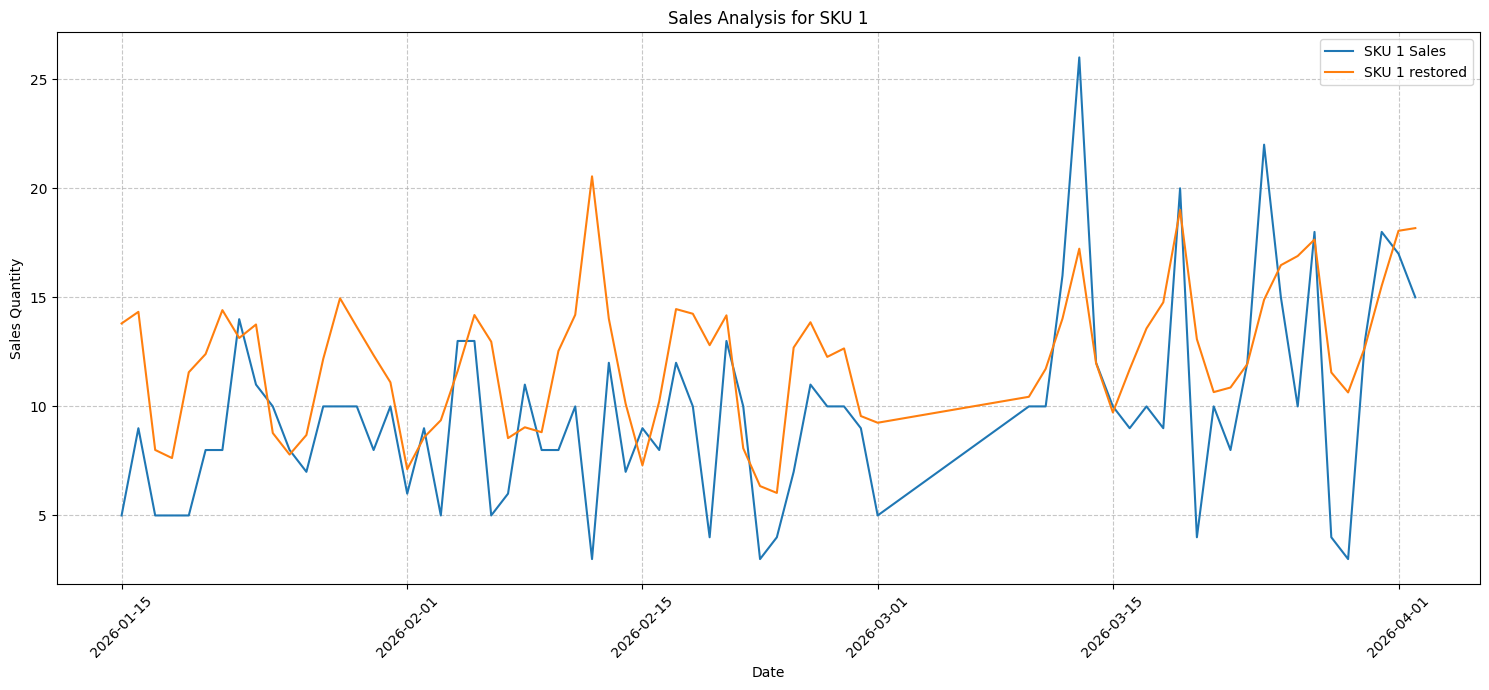

In [53]:
lasts = daily.tail(70)
date = lasts['date']
import matplotlib.pyplot as plt

# 1. Увеличиваем размер (ширина=15, высота=7 дюймов)
plt.figure(figsize=(15, 7))

# 2. Строим график
plt.plot(date, lasts['SKU_2_sales'], label='SKU 1 Sales')
plt.plot(date, lasts['SKU_2_restored'], label='SKU 1 restored')


# Добавляем подписи
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.title('Sales Analysis for SKU 1')

# Добавляем сетку, чтобы было легче анализировать пики
plt.grid(True, linestyle='--', alpha=0.7)

# Если даты на оси X налезают друг на друга, можно их наклонить:
plt.xticks(rotation=45)

# Добавляем легенду
plt.legend()

# Показываем результат
plt.tight_layout() # Автоматически подгоняет отступы, чтобы подписи не обрезались
plt.show()

In [52]:
(lasts['SKU_1_restored'] - lasts['SKU_1_sales']).mean()

np.float64(7.509260102650179)

In [210]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')


def load_env_file(path: str | Path = '.env') -> dict[str, str]:
    env = {}
    path = Path(path)
    if not path.exists():
        return env
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env[key.strip()] = value.strip()
    return env


env = load_env_file('C:/Users/dns/Desktop/Projects/demand-forecasting-model/.env')
host = env.get('HOST', os.getenv('HOST'))
port = env.get('PORT', os.getenv('PORT'))
username = env.get('USER', os.getenv('USER'))
password = env.get('PASSWORD', os.getenv('PASSWORD'))
database = env.get('DATABASE', os.getenv('DATABASE'))
print(host, port, username, database)

client = clickhouse_connect.get_client(
    host=host,
    port=port,
    username=username,
    password=password,
    database=database,
)


rc1b-aergg94cc1r6ctr1.mdb.yandexcloud.net 8443 AlmazZR Svezhar


In [211]:
df_sql = client.query_df("""
  SELECT DISTINCT
      fcl.*,
      dbs.bakery_name bakery_name,
      dbs.city city,
      dbs.price_region price_region,
      dps.product_name product_name,
      dps.category_name category_name
  FROM Svezhar.fct_check_lines AS fcl
  JOIN Svezhar.dim_bakeries AS dbs
      ON fcl.bakery_id = dbs.bakery_id
  JOIN Svezhar.dim_products AS dps
      ON fcl.product_id = dps.product_id
  WHERE dbs.bakery_name = 'Проспект Победы 147 Казань'
""")

df_sql.columns = [col.split('.')[-1] for col in df_sql.columns]

In [249]:
tailsql = df_sql[df_sql['product_name'] == SKU_1].groupby('check_date', as_index=False)['quantity'].sum().rename(columns={'quantity': f"{SKU_1}_qty"}).tail(40)

In [241]:
df_sql.columns

Index(['check_id', 'line_id', 'check_number', 'document_number',
       'check_datetime', 'check_date', 'operation_type', 'cash_event_type',
       'product_id', 'freshness', 'quantity', 'price', 'discount_amount',
       'line_amount', 'kkt_id', 'bakery_id', 'payment_type', 'bakery_name',
       'city', 'price_region', 'product_name', 'category_name'],
      dtype='object')

In [223]:
tailsql.groupby('check_date', as_index=False)['quantity'].sum().rename(columns={'quantity': "bakery_hour_qty"})

,check_date,bakery_hour_qty
0,2026-05-05,12.214
1,2026-05-06,22.722
2,2026-05-07,9.000


In [242]:
# Убедимся, что время в нужном формате
df_sql['check_datetime'] = pd.to_datetime(df_sql['check_datetime'])
df_sql['check_date'] = pd.to_datetime(df_sql['check_date'])

# Извлекаем час и день недели
df_sql['hour'] = df_sql['check_datetime'].dt.hour
df_sql['week'] = df_sql['check_date'].dt.day_of_week

# Группируем чеки, чтобы получить суммарные продажи пекарни по часам
sql_hourly = df_sql.groupby(['check_date', 'hour', 'week'], as_index=False)['quantity'].sum()
sql_hourly = sql_hourly.rename(columns={'quantity': 'bakery_total'})

In [244]:
# 1. Группируем чеки
sql_hourly = df_sql.groupby(['check_date', 'hour', 'week'], as_index=False)['quantity'].sum()
sql_hourly = sql_hourly.rename(columns={'quantity': 'bakery_total'})

# ИСПРАВЛЕНИЕ: Переводим Decimal в float, чтобы математика работала
sql_hourly['bakery_total'] = sql_hourly['bakery_total'].astype(float)

In [245]:
sql_restored = sql_hourly.copy()

for i, profile in enumerate(w_h_profiles, start=1):
    share_col = f"SKU_{i}_share_profile"
    restored_col = f"SKU_{i}_restored"
    
    # Присоединяем профиль (он сгруппирован по week и hour)
    sql_restored = sql_restored.merge(profile.rename(share_col), on=['week', 'hour'], how='left')
    
    # Считаем восстановленные продажи в штуках
    sql_restored[restored_col] = sql_restored[share_col] * sql_restored['bakery_total']

# Убираем NaN (если в какие-то часы профиль не определен)
sql_restored = sql_restored.fillna(0)

In [246]:
# Группируем по дате
# Возьмем общие продажи пекарни и все колонки с восстановленными SKU
target_cols = ['bakery_total'] + [col for col in sql_restored.columns if 'restored' in col]
daily_sql = sql_restored.groupby('check_date', as_index=False)[target_cols].sum()

# Теперь можно сделать tail(40)
tailsql_restored = daily_sql.tail(40)

In [248]:
lasts_sql

,check_date,bakery_total,SKU_1_restored,SKU_2_restored,SKU_3_restored,SKU_4_restored
356,2026-03-30,841.888,63.174951,13.416841,36.856107,40.115679
357,2026-03-31,908.250,71.199957,17.541777,43.320252,49.836378
358,2026-04-01,923.434,80.915817,18.064329,48.294687,46.308075
359,2026-04-02,877.278,69.273100,20.005850,53.117074,43.536953
360,2026-04-03,970.847,85.185423,22.869677,46.209654,43.172623
361,2026-04-04,635.365,46.445826,13.477664,33.279101,24.980289
362,2026-04-05,790.249,71.549475,21.083763,40.679489,32.851682
363,2026-04-06,714.312,54.005033,11.571110,31.033076,34.857046
364,2026-04-07,955.460,75.426091,18.865867,46.709206,50.815429
365,2026-04-08,866.590,76.538568,16.486554,44.399330,42.715504


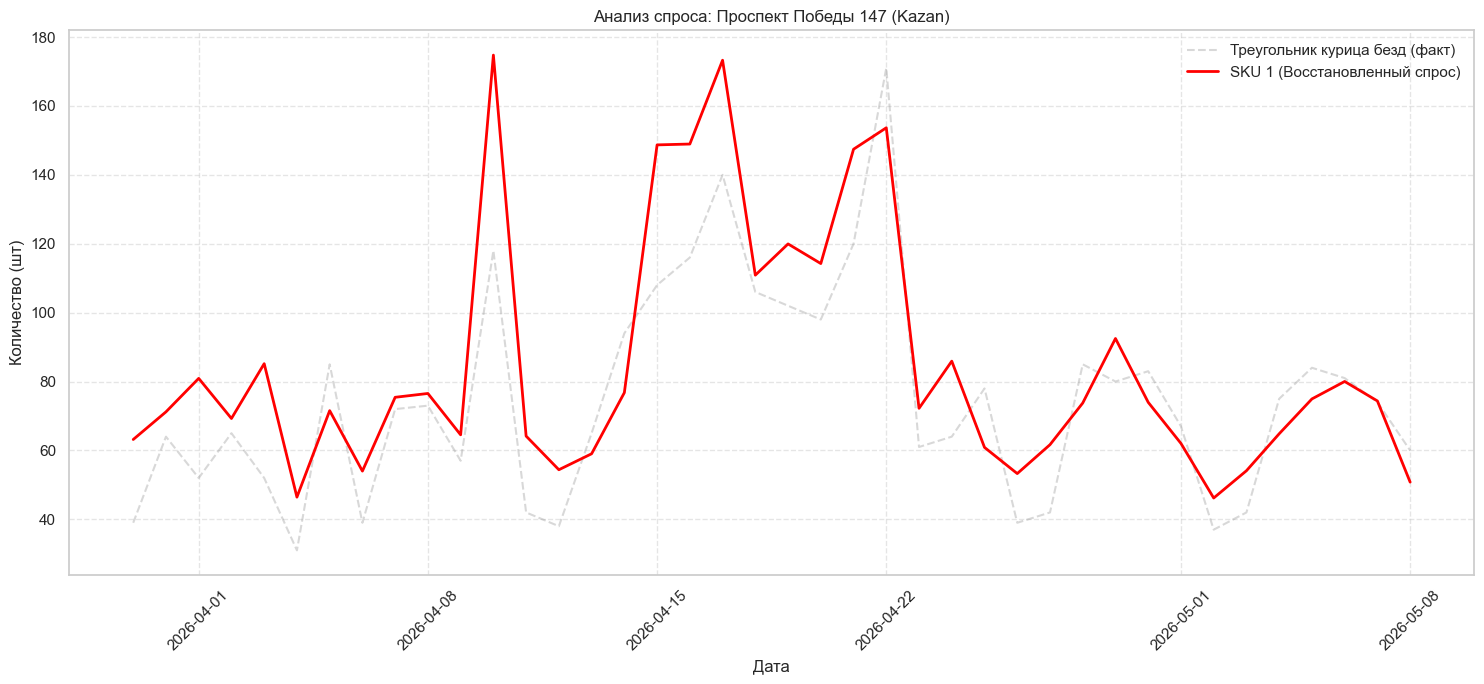

In [251]:
# Берем последние 40 дней из обработанных SQL данных
lasts_sql = daily_sql.tail(40) 

# Указываем колонку с датой (в SQL она check_date)
date_sql = lasts_sql['check_date']

plt.figure(figsize=(15, 7))

# Строим реальные продажи всей пекарни (для контекста)
# Если ты вытаскивал реальные продажи SKU_1 в этой пекарне, замени bakery_total на них
plt.plot(date_sql, tailsql[f"{SKU_1}_qty"], label=f'{SKU_1} (факт)', color='gray', alpha=0.3, linestyle='--')

# Строим восстановленный спрос для SKU 1
plt.plot(date_sql, lasts_sql['SKU_1_restored'], label='SKU 1 (Восстановленный спрос)', color='red', linewidth=2)

# Если ты добавил в daily_sql реальные продажи этого SKU, можно вывести и их для сравнения:
if 'SKU_1_sales' in lasts_sql.columns:
    plt.plot(date_sql, lasts_sql['SKU_1_sales'], label='SKU 1 (Реальные продажи)', color='blue', marker='o')

# Оформление
plt.xlabel('Дата')
plt.ylabel('Количество (шт)')
plt.title('Анализ спроса: Проспект Победы 147 (Kazan)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()